# 📊 PPT/PDF Extractor V3 - High Quality + Visual Verification

**Improvements over V2:**
- ✅ **Qwen2-VL-7B** model (3.5x more powerful than 2B)
- ✅ **Side-by-side image comparison** for verification
- ✅ **Better JSON parsing** (no more truncation)
- ✅ **Improved prompts** for complete extraction
- ✅ **4-bit quantization** option for memory efficiency

---

⚠️ **IMPORTANT**: Enable T4 GPU: **Runtime → Change runtime type → T4 GPU**

## Step 1: Install Dependencies

In [ ]:
%%time
# Core dependencies
!pip install -q pymupdf Pillow tqdm

# Qwen2-VL dependencies
!pip install -q transformers accelerate qwen-vl-utils

# For 4-bit quantization (reduces memory, allows 7B model)
!pip install -q bitsandbytes

# For image display
!pip install -q ipywidgets

print("\n✅ All dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.0 MB/s eta 0:00:00

✅ All dependencies installed!
CPU times: user 7.86 s, sys: 1.07 s, total: 8.93 s
Wall time: 44.1 s


In [ ]:
import torch
import gc
import os
import io
import json
import re
import fitz  # PyMuPDF
from PIL import Image
from tqdm.notebook import tqdm
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from io import BytesIO
import base64
import warnings
warnings.filterwarnings('ignore')

# Check GPU
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"✅ GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("❌ NO GPU! Go to: Runtime → Change runtime type → T4 GPU")
    raise SystemExit()

✅ GPU: Tesla T4 (14.7 GB)


## Step 2: Load Qwen2-VL-7B Model

Using **4-bit quantization** to fit the 7B model in T4 GPU memory while maintaining quality.

In [ ]:
%%time
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

# Model selection
MODEL_NAME = "Qwen/Qwen2-VL-7B-Instruct"  # 7B is much better than 2B

print(f"🔄 Loading {MODEL_NAME}...")
print("   Using 4-bit quantization for memory efficiency")
print("   (First run downloads ~8GB, takes 5-7 minutes)\n")

# 4-bit quantization config - fits 7B model in ~8GB VRAM
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)

processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Memory stats
allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3

print(f"\n✅ Model loaded successfully!")
print(f"   GPU Memory: {allocated:.1f} GB allocated / {reserved:.1f} GB reserved")
print(f"   Free for inference: ~{gpu_mem - reserved:.1f} GB")

🔄 Loading Qwen/Qwen2-VL-7B-Instruct...
   Using 4-bit quantization for memory efficiency
   (First run downloads ~8GB, takes 5-7 minutes)



config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model-00004-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]


✅ Model loaded successfully!
   GPU Memory: 5.5 GB allocated / 7.8 GB reserved
   Free for inference: ~6.9 GB
CPU times: user 1min 40s, sys: 55.6 s, total: 2min 36s
Wall time: 4min 33s


## Step 3: Setup Extraction Functions

In [ ]:
@dataclass
class PageImage:
    page_number: int
    image: Image.Image
    width: int
    height: int

def pdf_to_images(pdf_path: str, zoom: float = 1.5,
                  start_page: int = 0, end_page: int = None) -> List[PageImage]:
    """Convert PDF pages to images"""
    doc = fitz.open(pdf_path)
    end = end_page if end_page else doc.page_count
    images = []

    print(f"📑 Converting pages {start_page+1} to {end}...")

    for i in tqdm(range(start_page, end), desc="Converting"):
        page = doc[i]
        mat = fitz.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=mat, alpha=False)
        img = Image.open(io.BytesIO(pix.tobytes("png")))
        images.append(PageImage(i + 1, img, pix.width, pix.height))

    doc.close()
    return images

print("✅ PDF converter ready!")

✅ PDF converter ready!


In [ ]:
# Improved extraction prompt - more structured and complete
EXTRACTION_PROMPT = '''You are an expert document analyzer. Analyze this presentation slide image thoroughly and extract ALL visible information.

IMPORTANT: Extract EVERY piece of text, number, and data point visible on the slide. Do not summarize or skip anything.

Return a valid JSON object with this exact structure:
{
    "slide_title": "The main title/heading of the slide",
    "slide_number": "Page number if visible, otherwise null",
    "slide_type": "One of: title, content, chart, table, diagram, mixed",
    "all_text": ["Every single text element on the slide as separate items"],
    "headings": ["All section headings or subtitles"],
    "bullet_points": ["All bullet point items"],
    "numerical_data": {
        "metric_name": "value with units"
    },
    "tables": [
        {
            "table_title": "Title if any",
            "headers": ["column1", "column2"],
            "rows": [["row1col1", "row1col2"], ["row2col1", "row2col2"]]
        }
    ],
    "charts": [
        {
            "chart_type": "bar/line/pie/other",
            "chart_title": "Title of the chart",
            "data_points": {"label": "value"},
            "axes": {"x_axis": "label", "y_axis": "label"},
            "description": "What the chart shows"
        }
    ],
    "key_takeaways": ["Main insights or conclusions from this slide"],
    "visual_elements": ["Logos, images, icons, diagrams described"]
}

Rules:
1. Extract ALL text exactly as shown - do not paraphrase
2. For tables, capture EVERY cell value
3. For charts, read ALL data labels and values
4. Include currency symbols, percentages, units
5. If a field has no data, use empty array [] or empty object {}
6. Return ONLY valid JSON, no other text'''

def robust_json_parse(text: str) -> Dict:
    """Robust JSON parser that handles common issues"""

    # Remove markdown code blocks
    if "```json" in text:
        text = text.split("```json")[1].split("```")[0]
    elif "```" in text:
        parts = text.split("```")
        if len(parts) >= 2:
            text = parts[1]

    # Find JSON object boundaries
    start = text.find("{")
    if start == -1:
        return {"raw_text": text.strip()}

    # Find matching closing brace
    depth = 0
    end = start
    for i, char in enumerate(text[start:], start):
        if char == "{":
            depth += 1
        elif char == "}":
            depth -= 1
            if depth == 0:
                end = i + 1
                break

    json_str = text[start:end]

    # Try to parse
    try:
        return json.loads(json_str)
    except json.JSONDecodeError as e:
        # Try fixing common issues
        # Remove trailing commas
        json_str = re.sub(r',\s*}', '}', json_str)
        json_str = re.sub(r',\s*]', ']', json_str)

        # Try again
        try:
            return json.loads(json_str)
        except:
            return {"raw_text": text.strip(), "parse_error": str(e)}

def extract_from_image(image: Image.Image, prompt: str = EXTRACTION_PROMPT) -> Dict:
    """Extract information from a single image using Qwen2-VL-7B"""

    # Resize if too large (helps with memory and speed)
    max_size = 1280
    if max(image.size) > max_size:
        ratio = max_size / max(image.size)
        new_size = (int(image.size[0] * ratio), int(image.size[1] * ratio))
        image = image.resize(new_size, Image.LANCZOS)

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=4096,  # Increased for complete extraction
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id
        )

    # Decode output
    generated = output_ids[0][len(inputs.input_ids[0]):]
    output_text = processor.decode(generated, skip_special_tokens=True)

    # Parse JSON robustly
    return robust_json_parse(output_text)

print("✅ Extraction function ready!")

✅ Extraction function ready!


## Step 4: Upload Your PDF

In [ ]:
from google.colab import files

print("📁 Select your PDF file:")
uploaded = files.upload()

pdf_file = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {pdf_file}")

# Get info
doc = fitz.open(pdf_file)
total_pages = doc.page_count
file_size = os.path.getsize(pdf_file) / (1024*1024)
doc.close()

print(f"   Pages: {total_pages}")
print(f"   Size: {file_size:.1f} MB")
print(f"\n⏱️ Estimated time: {total_pages * 15}-{total_pages * 25} seconds")
print(f"   (~{total_pages * 20 / 60:.1f} minutes)")

📁 Select your PDF file:


Saving info.pdf to info.pdf

✅ Uploaded: info.pdf
   Pages: 38
   Size: 2.9 MB

⏱️ Estimated time: 570-950 seconds
   (~12.7 minutes)


## Step 5: Run Extraction

In [ ]:
# ═══════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════

ZOOM_FACTOR = 1.5   # Image quality (1.0=fast, 2.0=high quality)
START_PAGE = 0      # First page (0-indexed)
END_PAGE = 5    # Last page (None = all pages)

# ═══════════════════════════════════════════════════════════

In [ ]:
# Convert PDF to images
page_images = pdf_to_images(pdf_file, ZOOM_FACTOR, START_PAGE, END_PAGE)
print(f"✅ Converted {len(page_images)} pages to images")

📑 Converting pages 1 to 5...


Converting:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Converted 5 pages to images


In [ ]:
# Run extraction with progress
print("\n🤖 Extracting with Qwen2-VL-7B (4-bit)...")
print("   This is 3.5x more powerful than the 2B model!\n")

results = {
    "document_info": {
        "source_file": pdf_file,
        "total_pages": total_pages,
        "pages_processed": len(page_images),
        "extraction_model": "Qwen2-VL-7B-Instruct (4-bit)",
        "zoom_factor": ZOOM_FACTOR
    },
    "pages": []
}

# Store images for later visualization
stored_images = {}

for page_img in tqdm(page_images, desc="Extracting"):
    try:
        # Store image for visualization
        stored_images[page_img.page_number] = page_img.image.copy()

        result = extract_from_image(page_img.image)
        result["page_number"] = page_img.page_number
        result["dimensions"] = f"{page_img.width}x{page_img.height}"
        results["pages"].append(result)

        # Clear memory every 3 pages
        if page_img.page_number % 3 == 0:
            gc.collect()
            torch.cuda.empty_cache()

    except Exception as e:
        results["pages"].append({
            "page_number": page_img.page_number,
            "error": str(e)
        })
        print(f"\n⚠️ Error on page {page_img.page_number}: {str(e)[:50]}")

# Final cleanup
gc.collect()
torch.cuda.empty_cache()

# Summary
successful = sum(1 for p in results['pages'] if 'error' not in p)
print(f"\n✅ Done! Extracted {successful}/{len(results['pages'])} pages successfully.")


🤖 Extracting with Qwen2-VL-7B (4-bit)...
   This is 3.5x more powerful than the 2B model!



Extracting:   0%|          | 0/5 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



✅ Done! Extracted 5/5 pages successfully.


## Step 6: 🔍 Visual Verification - Side-by-Side Comparison

View the original slide image alongside the extracted information to verify accuracy.

In [ ]:
def image_to_base64(img: Image.Image, max_width: int = 500) -> str:
    """Convert PIL image to base64 for HTML display"""
    # Resize for display
    ratio = max_width / img.width
    new_size = (max_width, int(img.height * ratio))
    img_resized = img.resize(new_size, Image.LANCZOS)

    buffer = BytesIO()
    img_resized.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode()

def display_side_by_side(page_num: int):
    """Display page image and extracted info side by side"""

    # Find page data
    page_data = None
    for p in results['pages']:
        if p.get('page_number') == page_num:
            page_data = p
            break

    if not page_data:
        print(f"❌ Page {page_num} not found")
        return

    # Get image
    if page_num not in stored_images:
        print(f"❌ Image for page {page_num} not available")
        return

    img_b64 = image_to_base64(stored_images[page_num])

    # Build extracted info HTML
    info_html = f"<h3>📄 Page {page_num} - Extracted Information</h3>"

    if 'error' in page_data:
        info_html += f"<p style='color:red'>❌ Error: {page_data['error']}</p>"
    else:
        # Title
        if 'slide_title' in page_data:
            info_html += f"<p><b>📌 Title:</b> {page_data['slide_title']}</p>"

        # Type
        if 'slide_type' in page_data:
            info_html += f"<p><b>📋 Type:</b> {page_data['slide_type']}</p>"

        # All text / bullet points
        text_items = page_data.get('all_text', page_data.get('bullet_points', page_data.get('text_content', [])))
        if text_items:
            info_html += "<p><b>📝 Text Content:</b></p><ul>"
            for item in text_items[:15]:  # Limit display
                info_html += f"<li>{item}</li>"
            if len(text_items) > 15:
                info_html += f"<li><i>... and {len(text_items)-15} more items</i></li>"
            info_html += "</ul>"

        # Numerical data / metrics
        metrics = page_data.get('numerical_data', page_data.get('key_metrics', {}))
        if metrics:
            info_html += "<p><b>📊 Metrics/Data:</b></p><ul>"
            for k, v in list(metrics.items())[:10]:
                info_html += f"<li><b>{k}:</b> {v}</li>"
            info_html += "</ul>"

        # Tables
        tables = page_data.get('tables', [])
        if tables:
            info_html += "<p><b>📋 Tables:</b></p>"
            for i, table in enumerate(tables[:2]):  # Limit to 2 tables
                if 'headers' in table:
                    info_html += f"<p><i>Table {i+1}:</i> {table.get('table_title', '')}</p>"
                    info_html += "<table border='1' style='border-collapse:collapse;font-size:12px;'>"
                    info_html += "<tr>" + "".join(f"<th style='padding:4px;background:#e0e0e0;'>{h}</th>" for h in table['headers']) + "</tr>"
                    for row in table.get('rows', [])[:5]:  # Limit rows
                        info_html += "<tr>" + "".join(f"<td style='padding:4px;'>{c}</td>" for c in row) + "</tr>"
                    info_html += "</table>"

        # Charts
        charts = page_data.get('charts', [])
        if charts:
            info_html += "<p><b>📈 Charts:</b></p><ul>"
            for chart in charts:
                info_html += f"<li><b>{chart.get('chart_type', 'Chart')}:</b> {chart.get('chart_title', chart.get('description', 'No title'))}</li>"
                if 'data_points' in chart and chart['data_points']:
                    info_html += "<ul>"
                    for k, v in list(chart['data_points'].items())[:5]:
                        info_html += f"<li>{k}: {v}</li>"
                    info_html += "</ul>"
            info_html += "</ul>"

        # Key takeaways / insights
        takeaways = page_data.get('key_takeaways', page_data.get('key_insights', []))
        if takeaways:
            info_html += "<p><b>💡 Key Takeaways:</b></p><ul>"
            for t in takeaways:
                info_html += f"<li>★ {t}</li>"
            info_html += "</ul>"

        # Raw text fallback
        if 'raw_text' in page_data:
            info_html += f"<p><b>📄 Raw Output:</b></p><pre style='background:#f5f5f5;padding:10px;font-size:11px;max-height:300px;overflow:auto;'>{page_data['raw_text'][:1500]}</pre>"

    # Create side-by-side layout
    html = f'''
    <div style="display:flex; gap:20px; margin:20px 0; border:1px solid #ddd; padding:15px; border-radius:8px;">
        <div style="flex:1; text-align:center;">
            <h3>🖼️ Original Slide</h3>
            <img src="data:image/png;base64,{img_b64}" style="max-width:100%; border:1px solid #ccc; border-radius:4px;">
        </div>
        <div style="flex:1; overflow:auto; max-height:600px;">
            {info_html}
        </div>
    </div>
    '''

    display(HTML(html))

print("✅ Visual comparison function ready!")

✅ Visual comparison function ready!


IntSlider(value=5, continuous_update=False, description='Page:', max=5, min=1)


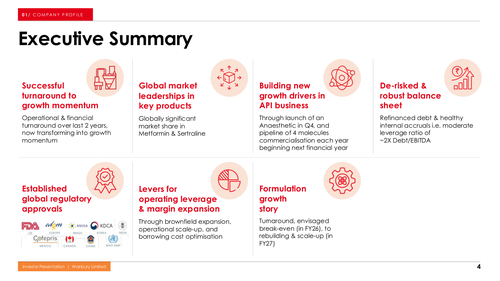

In [ ]:
# Interactive page viewer
print("🔍 Visual Verification - Compare extraction with original slide\n")

page_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=len(results['pages']),
    step=1,
    description='Page:',
    continuous_update=False
)

def on_page_change(change):
    clear_output(wait=True)
    display(page_slider)
    display_side_by_side(change['new'])

page_slider.observe(on_page_change, names='value')
display(page_slider)
display_side_by_side(1)

📊 Quick View - First 5 Pages




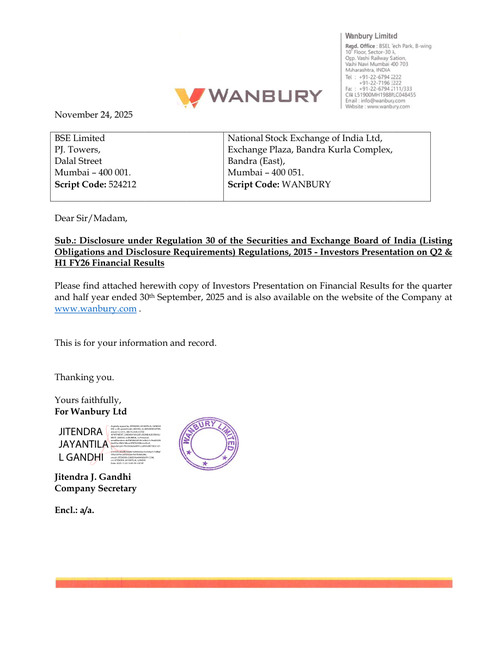


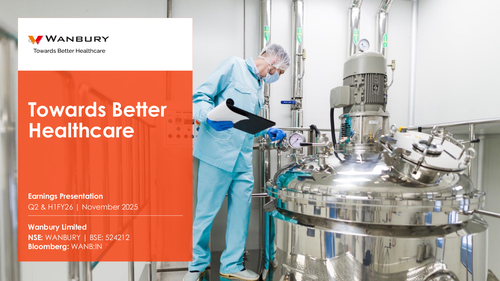


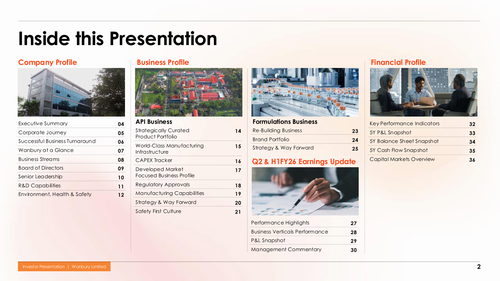


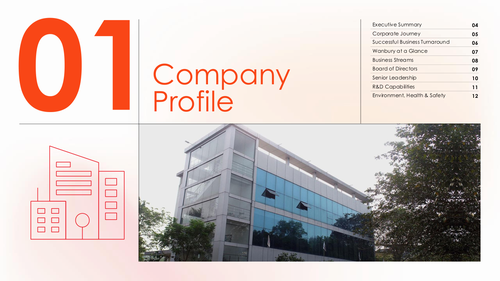


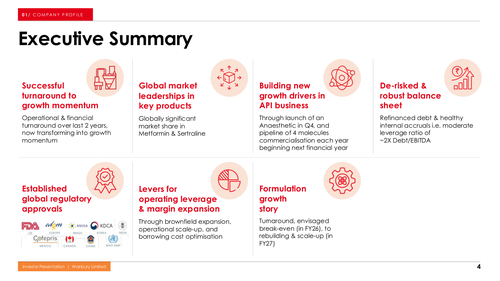

In [ ]:
# Quick view multiple pages
print("📊 Quick View - First 5 Pages\n")
print("="*80)

for page_num in range(1, min(6, len(results['pages'])+1)):
    display_side_by_side(page_num)
    print("\n" + "="*80 + "\n")

## Step 7: View All Results (Text Summary)

In [ ]:
# Summary statistics
successful = sum(1 for p in results['pages'] if 'error' not in p)
has_tables = sum(1 for p in results['pages'] if p.get('tables'))
has_charts = sum(1 for p in results['pages'] if p.get('charts'))
has_metrics = sum(1 for p in results['pages'] if p.get('numerical_data') or p.get('key_metrics'))

print("═" * 60)
print("📊 EXTRACTION SUMMARY")
print("═" * 60)
print(f"File: {results['document_info']['source_file']}")
print(f"Model: {results['document_info']['extraction_model']}")
print(f"Pages: {len(results['pages'])} processed")
print(f"Success Rate: {successful}/{len(results['pages'])} ({100*successful/len(results['pages']):.0f}%)")
print(f"\nContent Found:")
print(f"  • Pages with tables: {has_tables}")
print(f"  • Pages with charts: {has_charts}")
print(f"  • Pages with metrics: {has_metrics}")
print("═" * 60)

════════════════════════════════════════════════════════════
📊 EXTRACTION SUMMARY
════════════════════════════════════════════════════════════
File: info.pdf
Model: Qwen2-VL-7B-Instruct (4-bit)
Pages: 5 processed
Success Rate: 5/5 (100%)

Content Found:
  • Pages with tables: 0
  • Pages with charts: 0
  • Pages with metrics: 0
════════════════════════════════════════════════════════════


## Step 8: Download Results

In [ ]:
# Save and download JSON
output_json = f"{os.path.splitext(pdf_file)[0]}_extracted_7B.json"

with open(output_json, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✅ Saved: {output_json}")
files.download(output_json)

✅ Saved: info_extracted_7B.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create comprehensive text summary
lines = [
    f"COMPREHENSIVE EXTRACTION REPORT",
    f"{'='*60}",
    f"Source: {pdf_file}",
    f"Model: Qwen2-VL-7B-Instruct (4-bit quantized)",
    f"Total Pages: {total_pages}",
    f"{'='*60}",
    ""
]

for page in results['pages']:
    lines.append(f"\n{'─'*60}")
    lines.append(f"PAGE {page.get('page_number', '?')}")
    lines.append(f"{'─'*60}")

    if 'error' in page:
        lines.append(f"ERROR: {page['error']}")
        continue

    if 'slide_title' in page:
        lines.append(f"\nTITLE: {page['slide_title']}")

    if 'slide_type' in page:
        lines.append(f"TYPE: {page['slide_type']}")

    # Text content
    text_items = page.get('all_text', page.get('bullet_points', page.get('text_content', [])))
    if text_items:
        lines.append(f"\nTEXT CONTENT:")
        for item in text_items:
            lines.append(f"  • {item}")

    # Metrics
    metrics = page.get('numerical_data', page.get('key_metrics', {}))
    if metrics:
        lines.append(f"\nMETRICS/DATA:")
        for k, v in metrics.items():
            lines.append(f"  • {k}: {v}")

    # Tables
    tables = page.get('tables', [])
    if tables:
        lines.append(f"\nTABLES:")
        for i, table in enumerate(tables):
            lines.append(f"  Table {i+1}: {table.get('table_title', 'Untitled')}")
            if 'headers' in table:
                lines.append(f"    Headers: {' | '.join(table['headers'])}")
            for row in table.get('rows', [])[:5]:
                lines.append(f"    Row: {' | '.join(str(c) for c in row)}")

    # Charts
    charts = page.get('charts', [])
    if charts:
        lines.append(f"\nCHARTS:")
        for chart in charts:
            lines.append(f"  • {chart.get('chart_type', 'Chart')}: {chart.get('chart_title', chart.get('description', 'No title'))}")

    # Takeaways
    takeaways = page.get('key_takeaways', page.get('key_insights', []))
    if takeaways:
        lines.append(f"\nKEY TAKEAWAYS:")
        for t in takeaways:
            lines.append(f"  ★ {t}")

    # Raw text fallback
    if 'raw_text' in page:
        lines.append(f"\nRAW OUTPUT:")
        lines.append(page['raw_text'][:800])

output_txt = f"{os.path.splitext(pdf_file)[0]}_summary_7B.txt"
with open(output_txt, 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))

print(f"✅ Saved: {output_txt}")
files.download(output_txt)

✅ Saved: info_summary_7B.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## 💡 Model Comparison

| Model | Parameters | Memory | Quality | Speed |
|-------|------------|--------|---------|-------|
| Qwen2-VL-2B | 2B | ~5 GB | Good | ~10s/page |
| **Qwen2-VL-7B (4-bit)** | 7B | ~8 GB | **Excellent** | ~20s/page |
| Qwen2-VL-7B (16-bit) | 7B | ~14 GB | Excellent | ~15s/page |

## 🔧 Troubleshooting

| Issue | Solution |
|-------|----------|
| Out of memory | Reduce ZOOM_FACTOR to 1.0 |
| JSON parsing errors | Check 'raw_text' field for actual output |
| Slow processing | Normal: ~20s/page for 7B model |
| Poor quality | Increase ZOOM_FACTOR to 2.0 |

---

🎉 **V3 Features:**
- 3.5x more powerful 7B model
- Side-by-side visual verification
- Robust JSON parsing
- Interactive page slider
- Comprehensive extraction prompt